## Confusion Matrix

In the previous notebook I trained a Random Forest Classifier that achieved 80% accuracy in predicting customer satisfaction. However accuracy alone does not tell the full story. In this notebook I dig deeper by plotting a confusion matrix to understand exactly where the model is getting predictions right and where it is failing. this shows specifically how many unsatisfied customers are being incorrectly classified as satisfied, which is the most costly type of error from a business perspective.

In [1]:
import sys
sys.path.append("..")
from utils import *
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Load and clean the data
df = load_data()
df = clean_data(df)
print("Data loaded and cleaned:", df.shape)

Data loaded and cleaned: (114842, 22)


### Rebuilding the Model
Since each notebook runs independently the model is rebuilt here using the same parameters and random state as notebook 04 
to ensure the results are identical and consistent.

In [2]:
# Recreate features, target, split and model
# This is needed since each notebook runs independently
df["satisfaction"] = df["review_score"].apply(lambda x: 1 if x >= 4 else 0)

features = ["delivery_days", "delivered_late", "price", "freight_value",
            "payment_value", "payment_installments", "payment_type"]

X = pd.get_dummies(df[features], columns=["payment_type"], drop_first=True)
y = df["satisfaction"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Model ready")

Model ready


## Confusion Matrix
To better understand where the model is making errors, a confusion matrix is plotted to show how many customers were correctly and incorrectly classified as satisfied or unsatisfied.

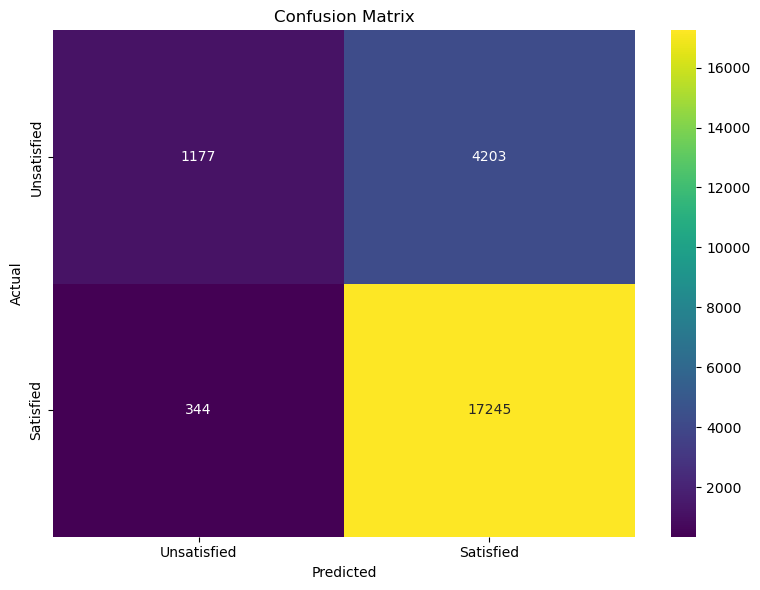

In [3]:
# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=["Unsatisfied", "Satisfied"],
    yticklabels=["Unsatisfied", "Satisfied"]
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### Confusion Matrix result explained 
The model correctly identified 17,245 satisfied customers and 1,177 unsatisfied customers. However it incorrectly classified 4,203 unsatisfied customers as satisfied, which represents the main weakness of the model. Only 344 satisfied customers were incorrectly labeled as unsatisfied. This confirms that the model is stronger at predicting satisfaction than dissatisfaction and that improving recall for unsatisfied customers should be the focus of any future model improvements.